# Analysis of QRC-ESN vs. Classical ESN Results

### **Notebook Objective**

This notebook analyzes the results generated by `01_run_experiments.ipynb`. Its purpose is to load the saved experimental data, identify the best-performing models, and visualize their performance without re-running any of the computationally expensive training processes.

### **Process**
1.  **Load Data**: Import the results from the `.csv` file.
2.  **Comparative Analysis**: Find the best hyperparameters for both QRC and Classical ESN models for each data profile based on the median Mean Squared Error (MSE).
3.  **Display Summaries**: Present the findings in clear, comparative tables.
4.  **Visualize**: (Placeholder) Generate plots to visually compare the performance of the best models on the time series data.

In [13]:
# === IMPORTS AND SETUP ===
import sys
import os

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Import our custom modules
from src.data_generation import (
    mackey_glass,
    generate_arma_data, generate_arma_input_driven_data,
    generate_narma_data, generate_narma_input_driven_data,
)
from src.visualization import (
    plot_best_model_comparison,
    plot_cv_split_overview,
    plot_cv_vs_test_scatter,
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Jupyter magic command for automatic reloading of external modules
%load_ext autoreload
%autoreload 2

# Pandas display options for better table formatting
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

print("Libraries and modules loaded successfully.")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Libraries and modules loaded successfully.


In [14]:
# === LOAD RESULTS DATA AND COMPUTE NMSE COLUMNS ===

RESULTS_FILENAME = '../data/results_comparative.csv'

try:
    results_df = pd.read_csv(RESULTS_FILENAME)
    print(f"Successfully loaded {len(results_df)} results from '{RESULTS_FILENAME}'.")
except FileNotFoundError:
    print(f"ERROR: The results file '{RESULTS_FILENAME}' was not found.")
    print("Please run the '01_run_experiments.ipynb' notebook first to generate the results.")
    results_df = pd.DataFrame()

# Compute NMSE columns post-hoc (median_test_nmse, median_cv_nmse).
# Helper handles both autoregressive and input-driven profiles via the
# DEFAULT_PROFILE_GENERATORS registry in src.analysis.
if not results_df.empty:
    from src.analysis import compute_nmse_columns
    results_df, var_cache = compute_nmse_columns(
        results_df, train_fraction=0.8, n_splits=5,
    )
    print(f"NMSE columns added. Profiles covered: "
          f"{sorted({p for p, _ in var_cache.keys()})}")
    results_df.head()

Successfully loaded 432 results from '../data/results_comparative.csv'.
NMSE columns added. Profiles covered: ['ARMA_InputDriven', 'Mackey_Glass_(tau=100)', 'Mackey_Glass_(tau=17)', 'Mackey_Glass_(tau=30)', 'NARMA10_InputDriven', 'NARMA5_InputDriven']


In [15]:
# === COMPARATIVE ANALYSIS ===
# Hyperparameter selection is performed on sliding-window CV MSE (median_cv_mse).
# The reported performance comes from the held-out test set, but values are
# displayed as NMSE (normalized by target variance per profile+window_size).
# Note: idxmin on CV MSE gives the same selection as idxmin on CV NMSE (within
# a profile both columns differ only by a constant divisor).

comparison_summary = []

if not results_df.empty:
    for profile_name in results_df['data_profile'].unique():
        profile_df = results_df[results_df['data_profile'] == profile_name]

        qrc_df = profile_df[profile_df['model_type'] == 'QRC'].dropna(subset=['median_cv_mse'])
        classical_df = profile_df[profile_df['model_type'] == 'Classical_ESN'].dropna(subset=['median_cv_mse'])

        if qrc_df.empty or classical_df.empty:
            print(f"--> INFO: Skipping profile '{profile_name}' due to missing results for one or both models.")
            continue

        best_qrc_row = qrc_df.loc[qrc_df['median_cv_mse'].idxmin()]
        best_classical_row = classical_df.loc[classical_df['median_cv_mse'].idxmin()]

        summary = {
            'Data Profile': profile_name,
            'QRC CV NMSE': best_qrc_row['median_cv_nmse'],
            'QRC Test NMSE': best_qrc_row['median_test_nmse'],
            'Classical CV NMSE': best_classical_row['median_cv_nmse'],
            'Classical Test NMSE': best_classical_row['median_test_nmse'],
            'QRC Stability (CV test)': best_qrc_row['cv_test_mse'],
            'Classical Stability (CV test)': best_classical_row['cv_test_mse']
        }
        comparison_summary.append(summary)

if comparison_summary:
    summary_df = pd.DataFrame(comparison_summary)
    print("--- Best Model Comparison (selected by CV MSE, reported as NMSE) ---")
    print(summary_df.to_string(index=False))
else:
    print("\nNo valid results found to generate a comparison summary.")

--- Best Model Comparison (selected by CV MSE, reported as NMSE) ---
          Data Profile  QRC CV NMSE  QRC Test NMSE  Classical CV NMSE  Classical Test NMSE  QRC Stability (CV test)  Classical Stability (CV test)
 Mackey_Glass_(tau=17)     0.000057       0.000040       7.435645e-07         4.348142e-07                 3.151272                       0.164190
 Mackey_Glass_(tau=30)     0.000090       0.000040       1.320788e-06         1.373592e-06                 2.219513                       0.100884
Mackey_Glass_(tau=100)     0.000064       0.000222       1.472922e-06         1.004810e-05                 0.626453                       0.041961
      ARMA_InputDriven     0.000103       0.000075       6.784629e-05         2.288532e-05                 1.940848                       3.164065
   NARMA10_InputDriven     0.429597       0.306108       1.392571e-01         8.063863e-02                 0.019785                       0.147119
    NARMA5_InputDriven     0.111420       0.11817

In [16]:
# === DETAILED HYPERPARAMETERS OF BEST MODELS ===
# Best configuration per (profile, model) is chosen by lowest median_cv_mse.

if not results_df.empty:
    valid_results_df = results_df.dropna(subset=['median_cv_mse'])

    best_models_df = valid_results_df.loc[
        valid_results_df.groupby(['data_profile', 'model_type'])['median_cv_mse'].idxmin()
    ]

    if not best_models_df.empty:
        print("\n--- Detailed Hyperparameters of Best Models (by CV MSE) ---")
        print(best_models_df.sort_values(by=['data_profile', 'model_type']).to_string())
    else:
        print("Could not determine the best models.")


--- Detailed Hyperparameters of Best Models (by CV MSE) ---
        model_type            data_profile  median_cv_mse    std_cv_mse  cv_cv_mse  median_test_mse  std_test_mse  cv_test_mse  leakage_rate    lambda_reg  window_size  n_layers  lag  base_seed  reservoir_size  spectral_radius  sparsity  test_var    cv_var  median_test_nmse  median_cv_nmse
256  Classical_ESN        ARMA_InputDriven   1.749030e-06  1.409777e-05   8.060337     4.729469e-07  1.496435e-06     3.164065           0.1  1.000000e-08            8       NaN  NaN       2025           100.0              0.9       0.1  0.020666  0.025779      2.288532e-05    6.784629e-05
224            QRC        ARMA_InputDriven   2.659573e-06  3.643299e-06   1.369881     1.546575e-06  3.001667e-06     1.940848           0.3  1.000000e-08            4       2.0  0.0       2025             NaN              NaN       NaN  0.020735  0.025935      7.458907e-05    1.025491e-04
213  Classical_ESN  Mackey_Glass_(tau=100)   6.746701e-08  1.90758


--- Generating plot for profile: Mackey_Glass_(tau=17) ---

Retraining best QRC model on full CV pool...
Best QRC Median Test NMSE: 0.000040


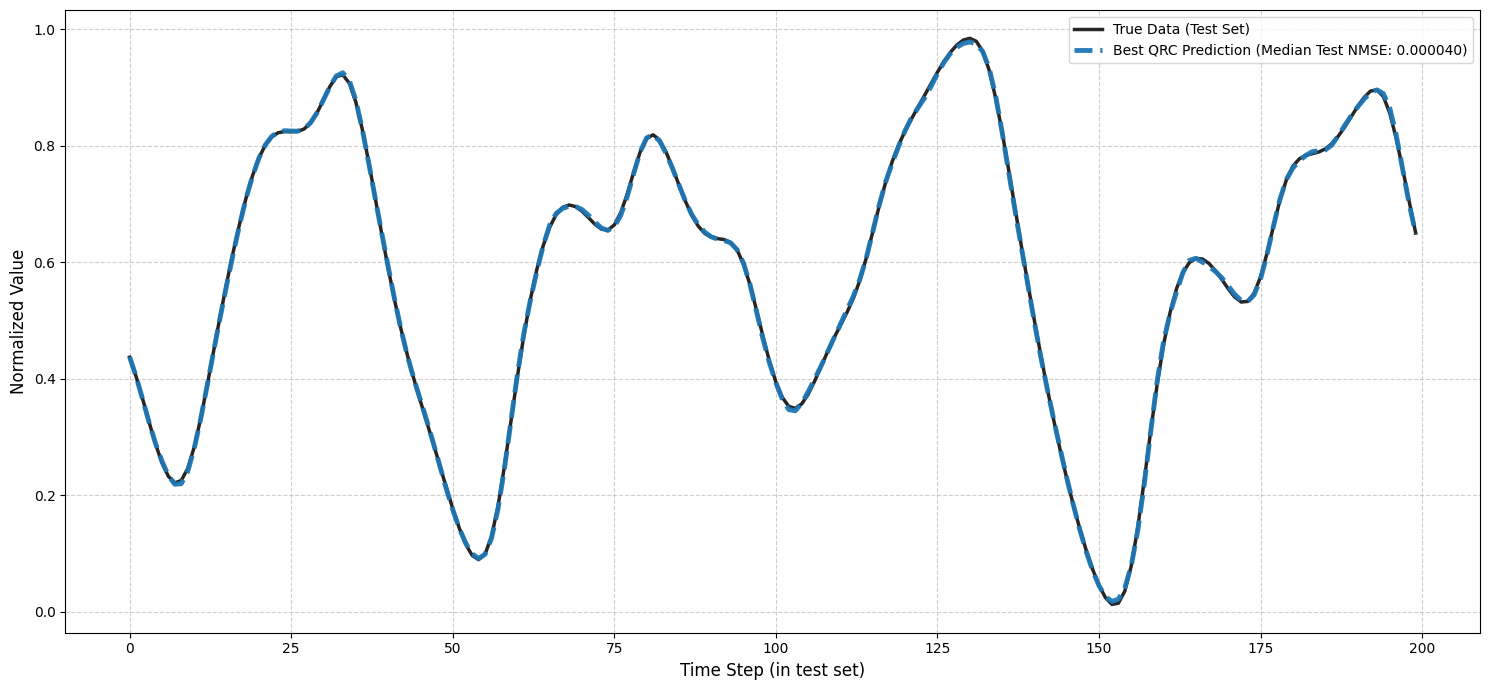


--- Generating plot for profile: Mackey_Glass_(tau=30) ---

Retraining best QRC model on full CV pool...
Best QRC Median Test NMSE: 0.000040


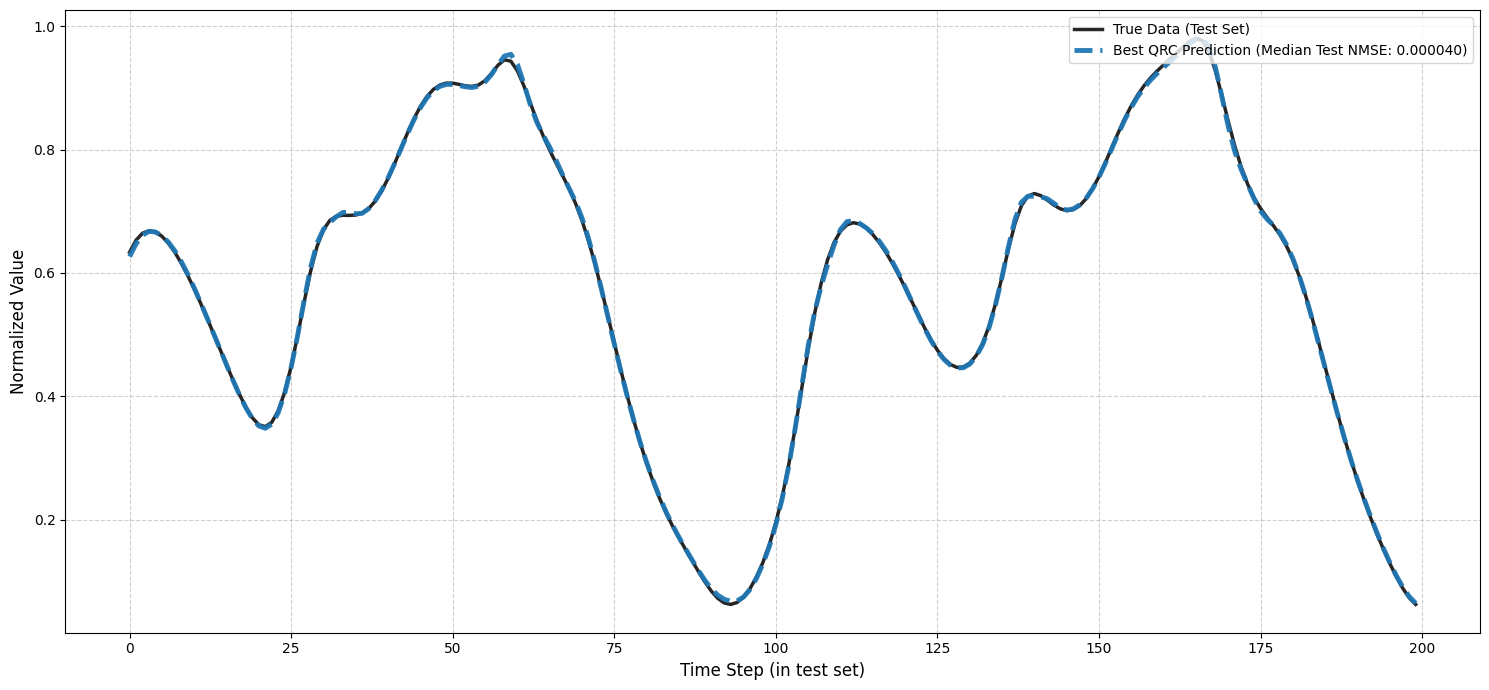


--- Generating plot for profile: Mackey_Glass_(tau=100) ---

Retraining best QRC model on full CV pool...
Best QRC Median Test NMSE: 0.000222


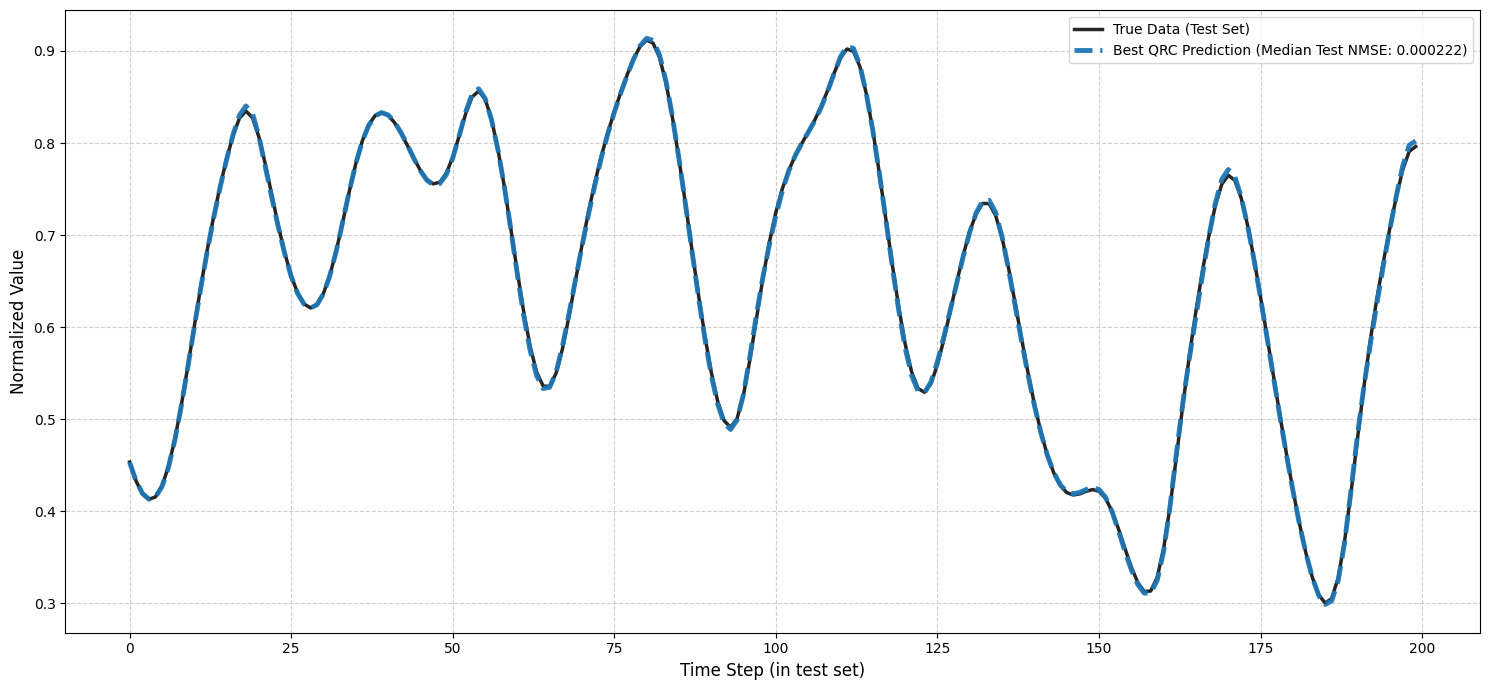


--- Generating plot for profile: ARMA_InputDriven ---

Retraining best QRC model on full CV pool...
Best QRC Median Test NMSE: 0.000075


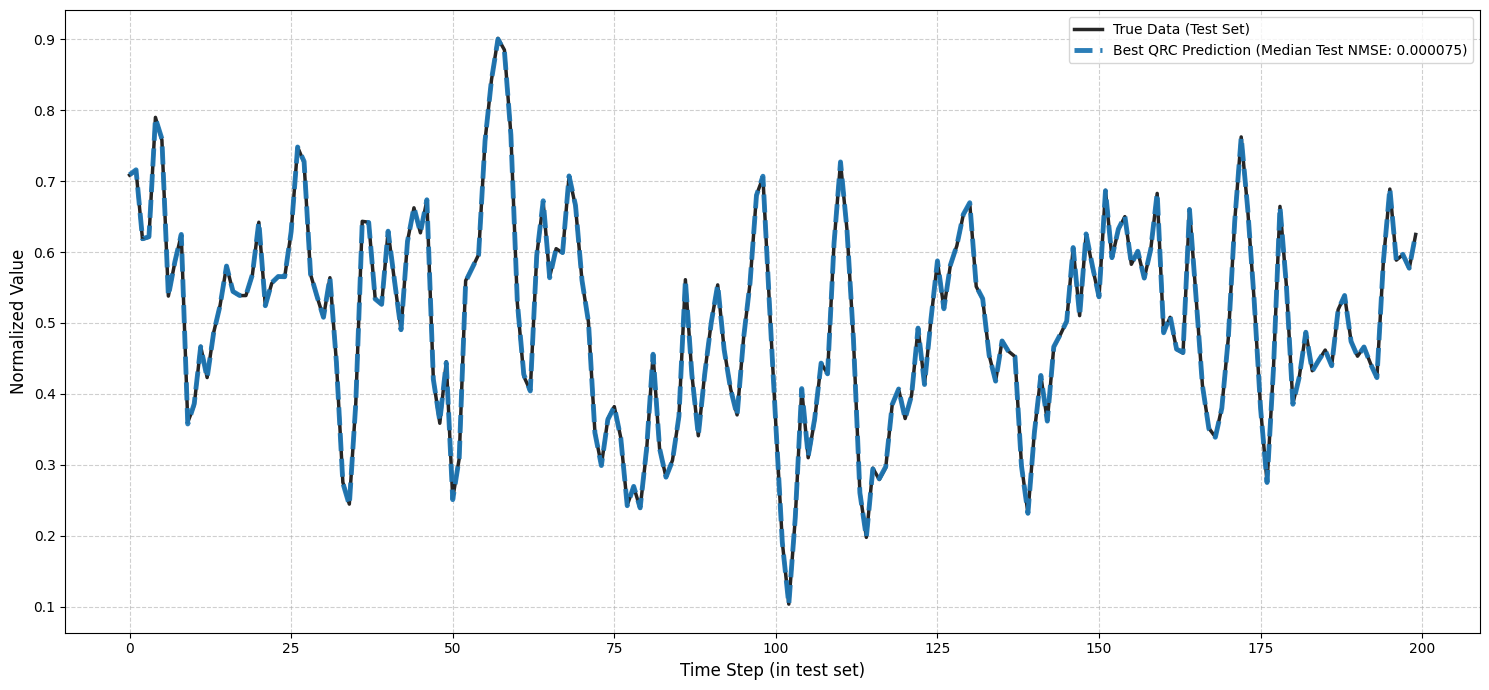


--- Generating plot for profile: NARMA10_InputDriven ---

Retraining best QRC model on full CV pool...
Best QRC Median Test NMSE: 0.306108


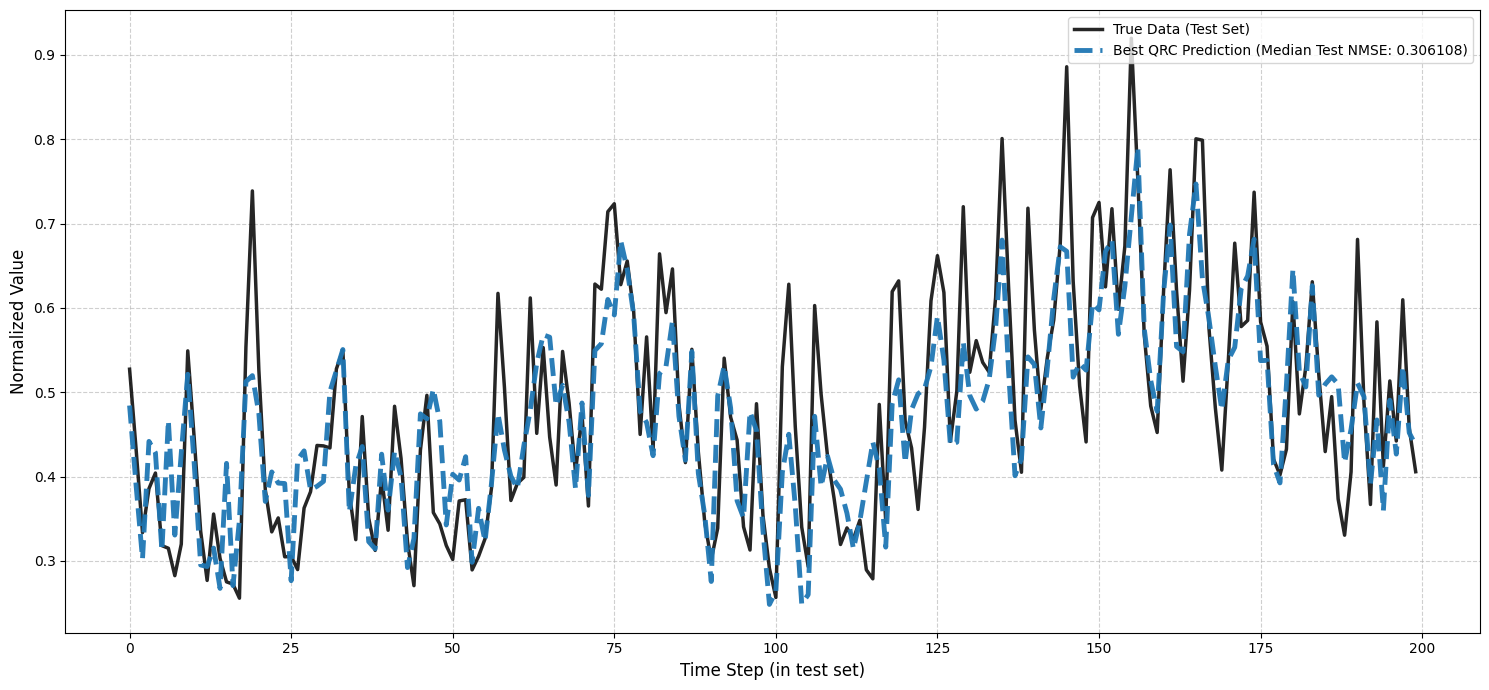


--- Generating plot for profile: NARMA5_InputDriven ---

Retraining best QRC model on full CV pool...
Best QRC Median Test NMSE: 0.118171


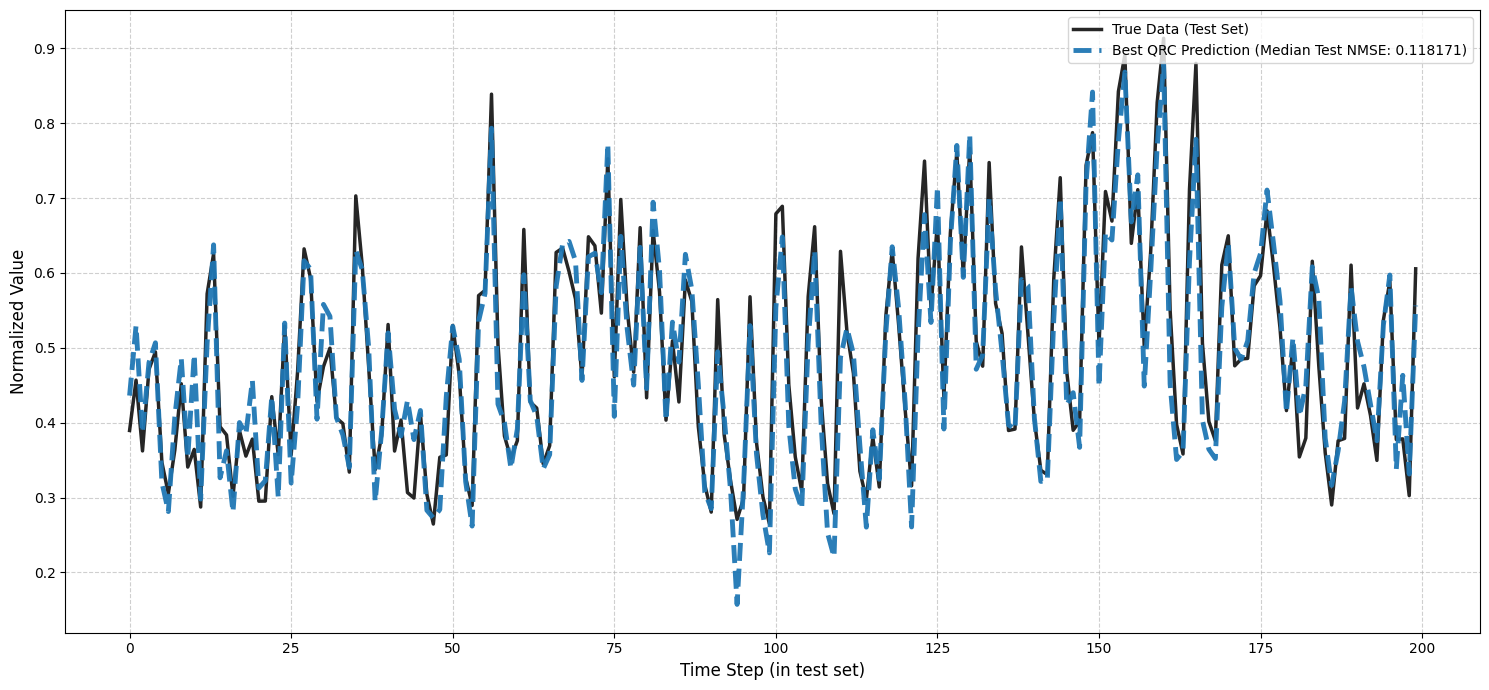

In [17]:
# === VISUALIZE BEST MODEL PERFORMANCE ===

# This cell iterates through each data profile, finds the best performing
# models (by CV MSE), and uses the dedicated plotting function from
# src/visualization.py to generate and display a comparative plot.

# Define constants needed for data regeneration
constants = {
    'TRAIN_FRACTION': 0.8,
    'N_SPLITS': 5,
    'WASHOUT': 100,
    'SEED': 2025
}

# Define the data profiles — includes BOTH legacy autoregressive AND new
# input-driven names so the notebook works against either CSV vintage. Only
# profiles actually present in the CSV are processed; the rest are silently
# skipped.
data_profiles_config = [
    {'name': 'Mackey_Glass_(tau=17)',  'generator': mackey_glass,                    'params': {'tau': 17}},
    {'name': 'Mackey_Glass_(tau=30)',  'generator': mackey_glass,                    'params': {'tau': 30}},
    {'name': 'Mackey_Glass_(tau=100)', 'generator': mackey_glass,                    'params': {'tau': 100}},
    # Legacy autoregressive
    {'name': 'ARMA_1_2_stochastic',    'generator': generate_arma_data,              'params': {}},
    {'name': 'NARMA10_Chaotic',        'generator': generate_narma_data,             'params': {'order': 10}},
    {'name': 'NARMA5_Chaotic',         'generator': generate_narma_data,             'params': {'order': 5}},
    # New input-driven
    {'name': 'ARMA_InputDriven',       'generator': generate_arma_input_driven_data, 'params': {}},
    {'name': 'NARMA10_InputDriven',    'generator': generate_narma_input_driven_data,'params': {'order': 10}},
    {'name': 'NARMA5_InputDriven',     'generator': generate_narma_input_driven_data,'params': {'order': 5}},
]


if not results_df.empty:
    profiles_in_csv = set(results_df['data_profile'].unique())
    for profile_config in data_profiles_config:
        profile_name = profile_config['name']

        # Skip profiles not in this CSV (handles legacy/input-driven mismatch silently)
        if profile_name not in profiles_in_csv:
            continue

        # Filter results for the current profile
        profile_df = results_df[results_df['data_profile'] == profile_name]

        # Selection is done on CV MSE
        qrc_df = profile_df[profile_df['model_type'] == 'QRC'].dropna(subset=['median_cv_mse'])
        classical_df = profile_df[profile_df['model_type'] == 'Classical_ESN'].dropna(subset=['median_cv_mse'])

        if qrc_df.empty or classical_df.empty:
            print(f"\n--> SKIPPING PLOT for '{profile_name}' due to missing results.")
            continue

        best_qrc_row = qrc_df.loc[qrc_df['median_cv_mse'].idxmin()]
        best_classical_row = classical_df.loc[classical_df['median_cv_mse'].idxmin()]

        # Existing one-step-ahead comparison plot (test set)
        plot_best_model_comparison(best_qrc_row, best_classical_row, profile_config, constants)
else:
    print("Results DataFrame is empty. Cannot generate plots.")


--- Generating CV split overview for profile: Mackey_Glass_(tau=17) ---



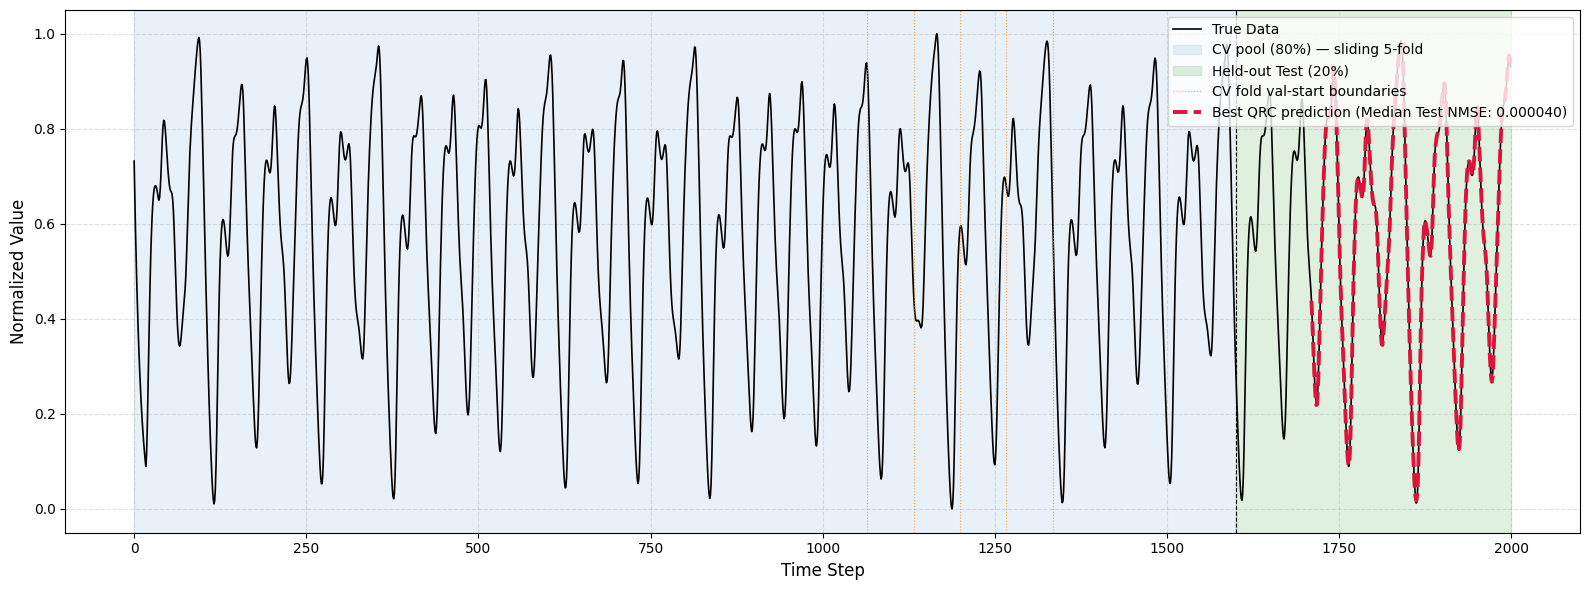


--- Generating CV split overview for profile: Mackey_Glass_(tau=30) ---



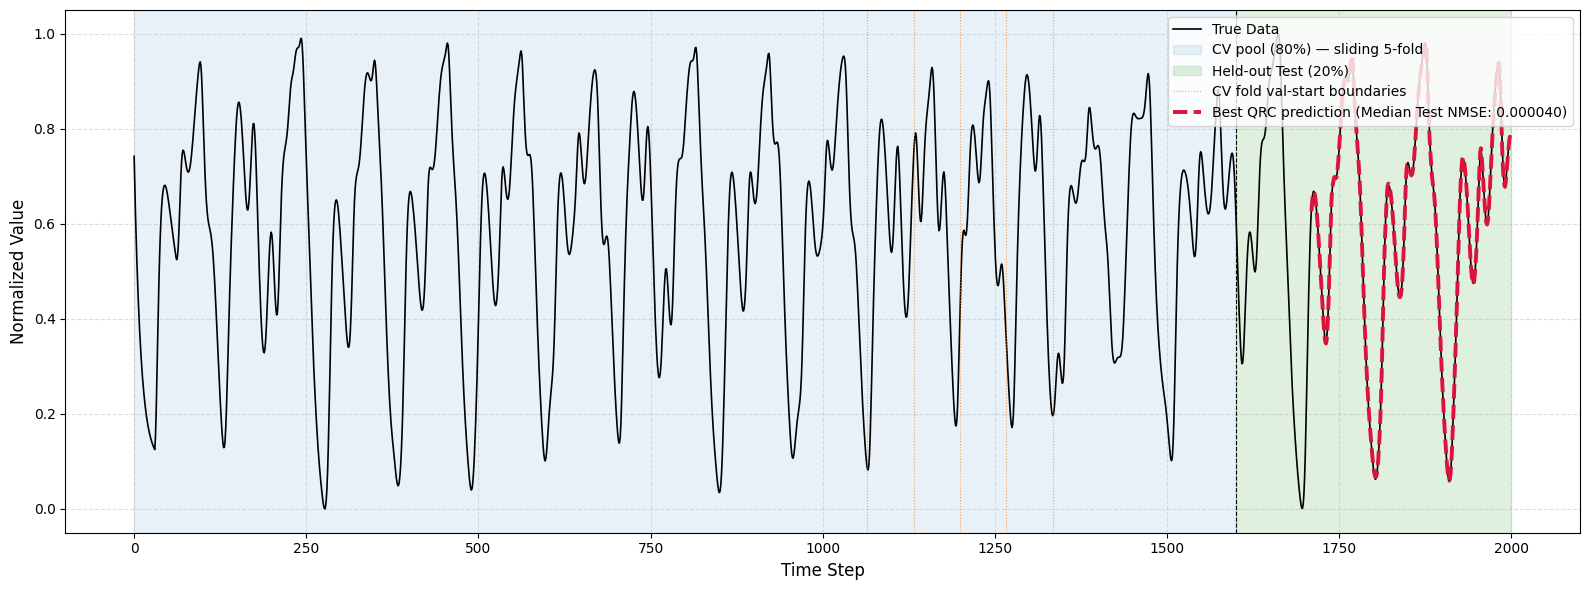


--- Generating CV split overview for profile: Mackey_Glass_(tau=100) ---



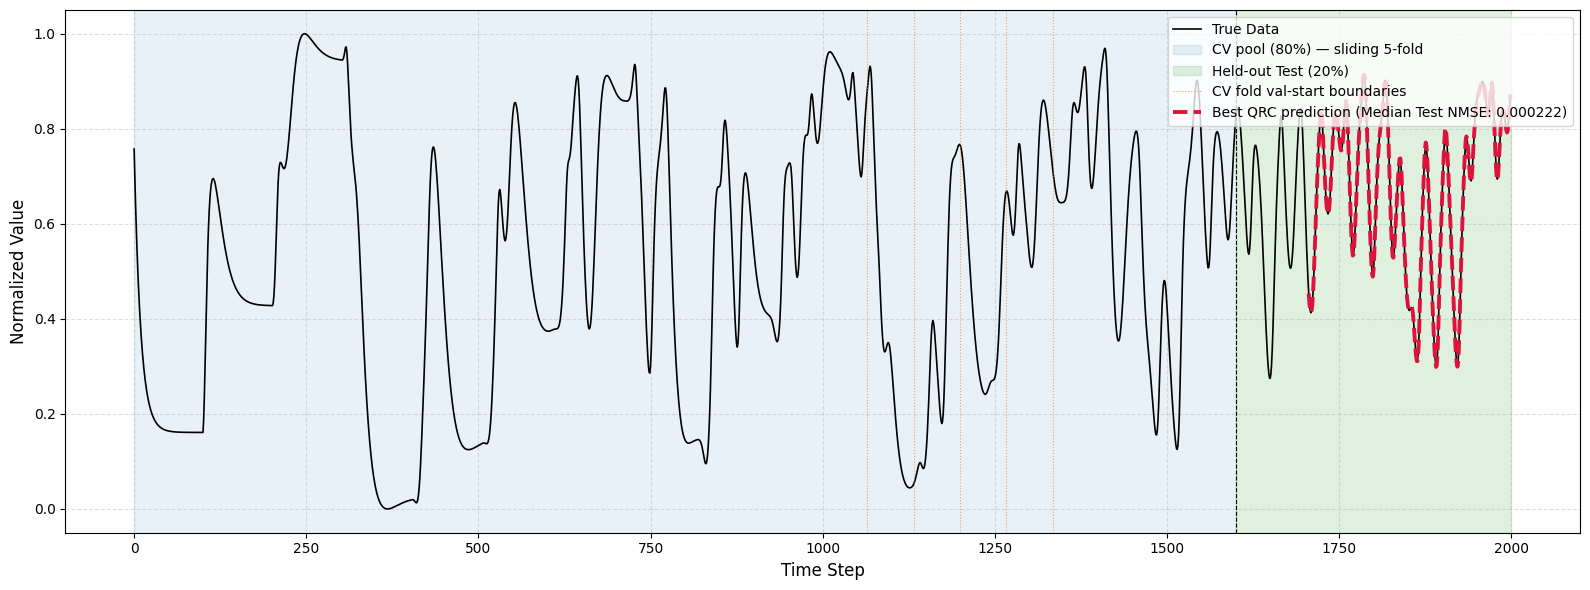


--- Generating CV split overview for profile: ARMA_InputDriven ---



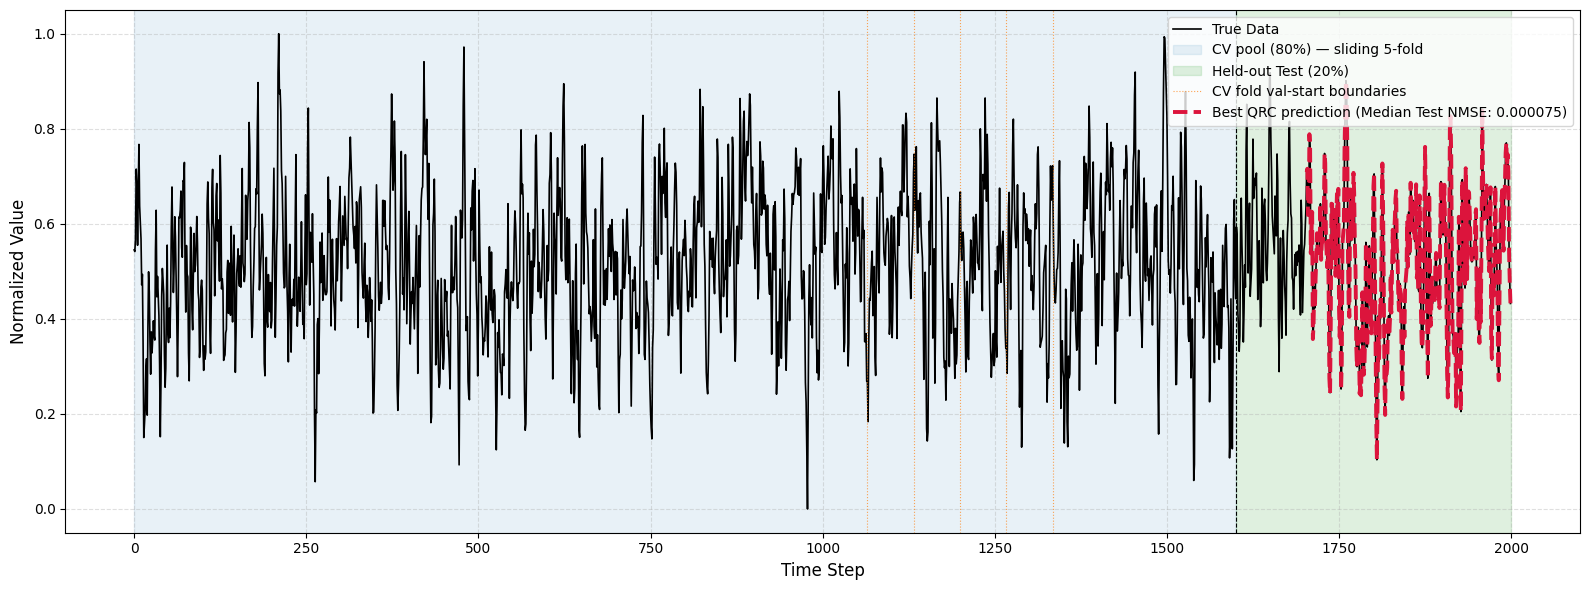


--- Generating CV split overview for profile: NARMA10_InputDriven ---



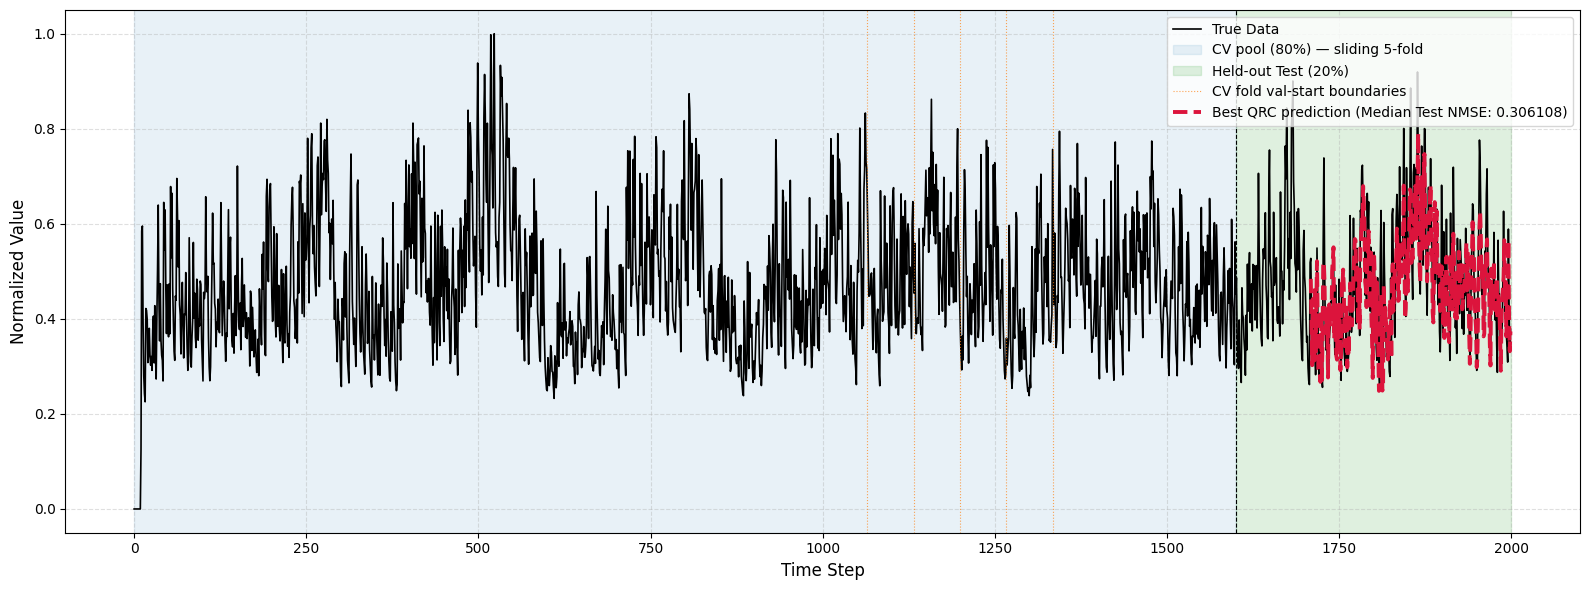


--- Generating CV split overview for profile: NARMA5_InputDriven ---



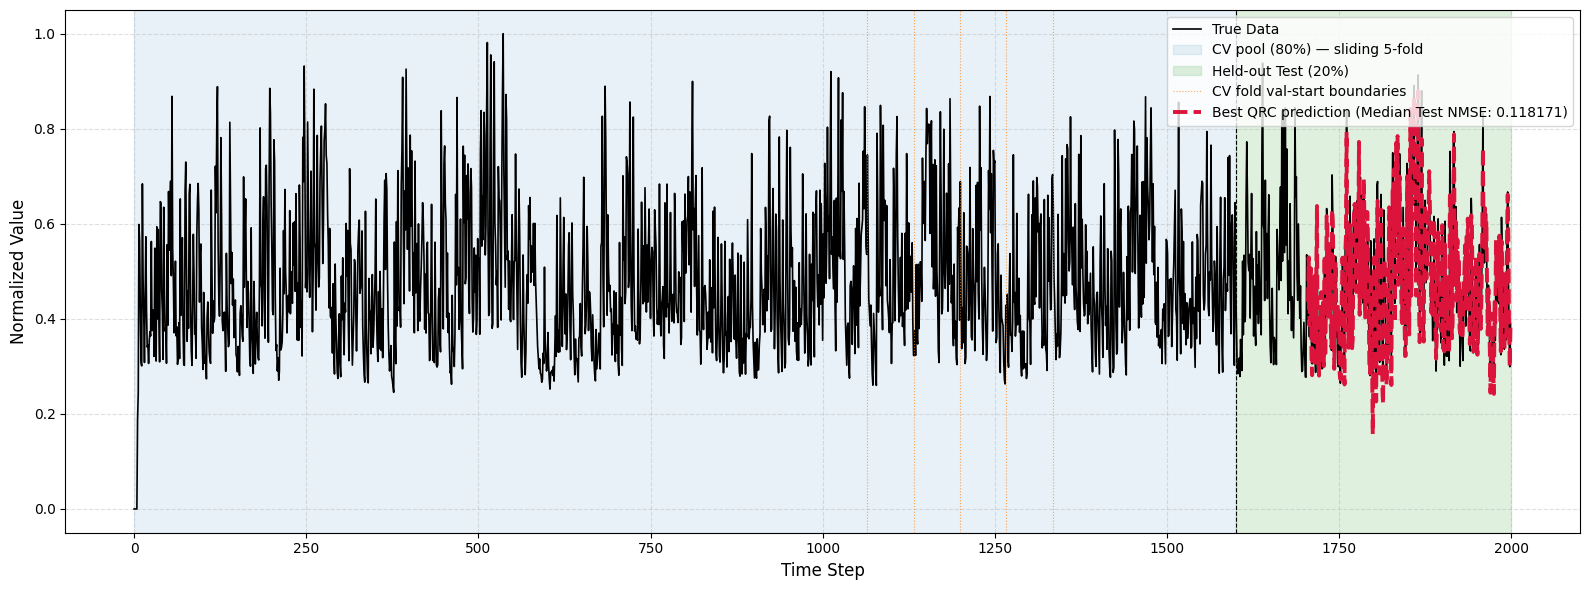

In [18]:
# === CV SPLIT OVERVIEW PLOTS ===
# Visualization: full time series with CV pool (80%) and held-out test (20%)
# regions shaded. Sliding-window CV fold val-boundaries are marked inside
# the CV pool, and the best QRC prediction is overlaid on the test segment.

if not results_df.empty:
    profiles_in_csv = set(results_df['data_profile'].unique())
    for profile_config in data_profiles_config:
        profile_name = profile_config['name']

        # Skip profiles not in this CSV
        if profile_name not in profiles_in_csv:
            continue

        profile_df = results_df[results_df['data_profile'] == profile_name]
        qrc_df = profile_df[profile_df['model_type'] == 'QRC'].dropna(subset=['median_cv_mse'])

        if qrc_df.empty:
            print(f"\n--> SKIPPING OVERVIEW for '{profile_name}' due to missing QRC results.")
            continue

        best_qrc_row = qrc_df.loc[qrc_df['median_cv_mse'].idxmin()]
        plot_cv_split_overview(best_qrc_row, profile_config, constants)
else:
    print("Results DataFrame is empty. Cannot generate overview plots.")

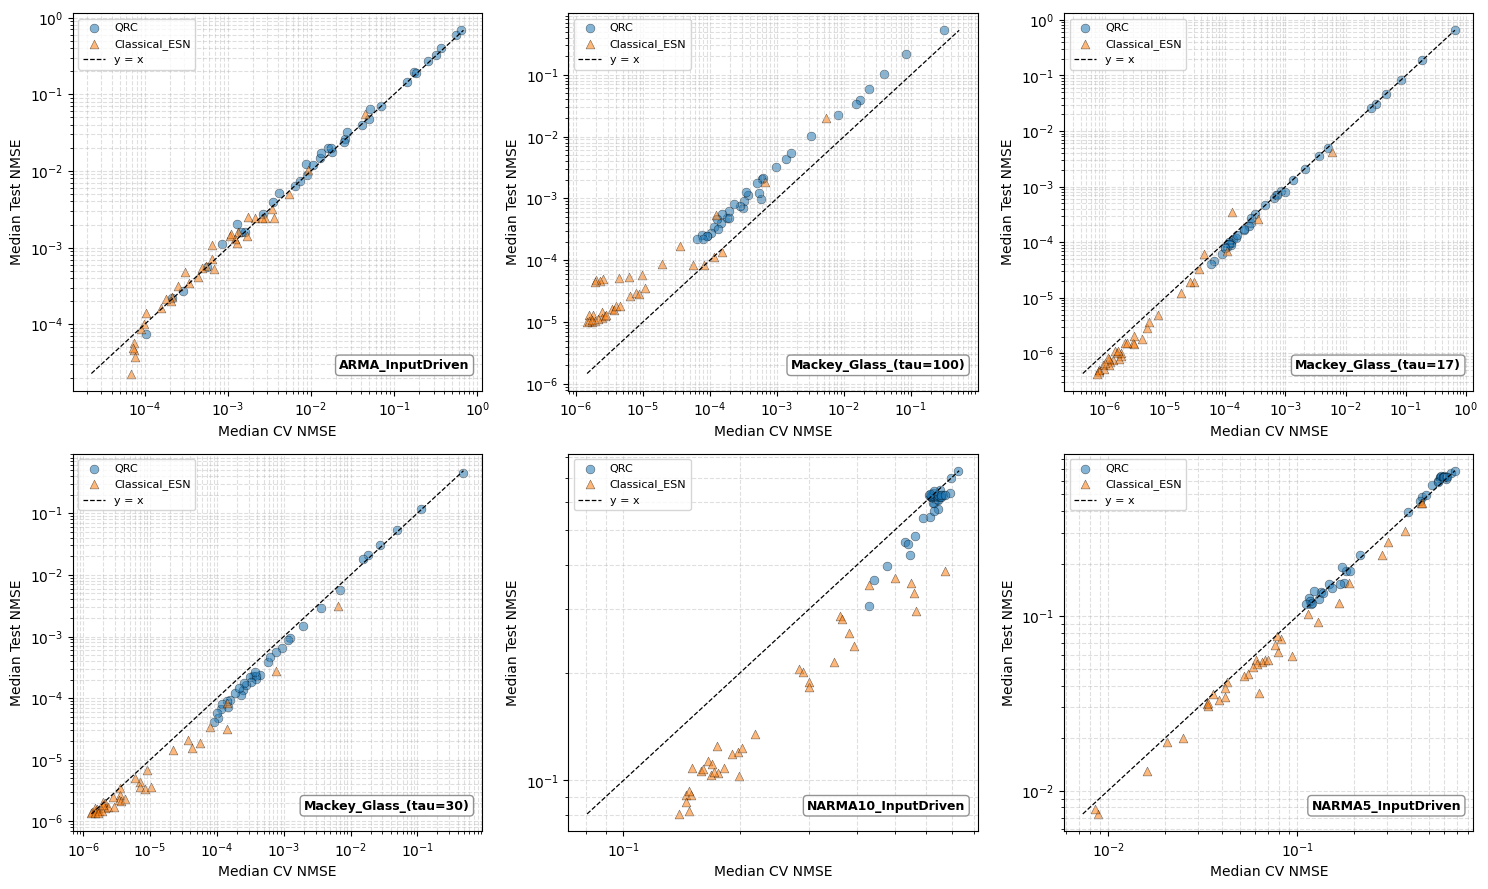

In [19]:
# === CV vs TEST SCATTER ("CV is honest") ===
# For every hyperparameter combination we have BOTH the K-fold sliding-window
# CV MSE and the held-out test MSE (Variant B). Plotting them against each
# other reveals whether CV selection is consistent with test performance:
# points close to the y=x line indicate honest CV. Systematic deviation would
# suggest the CV estimate is biased.

if not results_df.empty:
    plot_cv_vs_test_scatter(results_df)
else:
    print("Results DataFrame is empty. Cannot generate CV-vs-Test scatter.")